# 11 - Modeling QA  (v2 / vClaire — go-forward dataset)

QA on the LightGBM baselines for the **vClaire v2** dataset: 38 HiRISE images with a
far denser BoulderNet detection set than the v1 priority10 cohort. **This is the
dataset we analyse and report on**; [`10_modeling_qa.ipynb`](10_modeling_qa.ipynb) is
the frozen v1 baseline it supersedes.

The scientific question (PLAN_NewDetections.md §9): the v1 dataset hit a presence/AUC
≈ 0.55 ceiling under three independent framings, and the within-image diagnostic
attributed it to the 5 m/px CTX texture **signal floor** *given the labels then
available*. v2 changes two things at once — far denser, more-complete labels **and**
~4× more images — so this notebook re-runs the same diagnostics on v2 and the
within-image section isolates the label-completeness effect from the cohort-size
effect. The v1↔v2 comparison table lives in
[`docs/modeling_results.md`](../docs/modeling_results.md).

Sweeps are selected by [`src.modeling.sweep_select.pick_sweep`](../src/modeling/sweep_select.py)
filtered to `dataset_dir='dataset_v2'` (via each sweep's `sweep_meta.json`), so this
notebook always renders v2 runs and never a v1 run.


In [1]:
# Bootstrap order matters on Windows: import src.modeling BEFORE numpy so the
# DLL/OMP setup runs before MKL preloads libiomp5md.dll (see src/modeling/__init__.py).
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.modeling  # noqa: F401  -- side effect: DLL bootstrap

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling.sweep_select import pick_sweep

REPO_ROOT = Path(REPO_ROOT)
MODELS_ROOT = REPO_ROOT / 'models'
FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = 'dataset_v2'
LOIO_SCHEME = 'loio_nfold'

SWEEP_DIR = pick_sweep('regression', DATASET_DIR)
BIN_SWEEP_DIR = pick_sweep('binary', DATASET_DIR)
WITHIN_DIR = pick_sweep('within_image', DATASET_DIR)
print(f'regression sweep:   {SWEEP_DIR.name}')
print(f'binary sweep:       {BIN_SWEEP_DIR.name}')
print(f'within-image sweep: {WITHIN_DIR.name}')

aggregate = pd.read_parquet(SWEEP_DIR / 'aggregate.parquet')
summary = pd.read_parquet(SWEEP_DIR / 'summary.parquet')
# sweep.py defaults to all VARIANT_CONSTRUCTORS, which includes lightgbm_classification.
# Run in regression mode (continuous target -> int8 truncates to all-zero) it trains a
# degenerate trivial model, so drop it from the regression view; the real binary results
# come from the binary sweep below.
REG_VARIANTS = ['lightgbm_tweedie', 'lightgbm_log1p_huber', 'lightgbm_two_stage']
aggregate = aggregate[aggregate['variant'].isin(REG_VARIANTS)].reset_index(drop=True)
summary = summary[summary['variant'].isin(REG_VARIANTS)].reset_index(drop=True)
bin_aggregate = pd.read_parquet(BIN_SWEEP_DIR / 'aggregate.parquet')
bin_summary = pd.read_parquet(BIN_SWEEP_DIR / 'summary.parquet')
print(f'regression aggregate rows: {len(aggregate)}; folds/cell: '
      f'{summary.groupby(["variant","scale_idx"]).size().iloc[0]}')


regression sweep:   20260529T061553Z
binary sweep:       20260529T075754Z
within-image sweep: 20260529T142227Z
regression aggregate rows: 12; folds/cell: 38


In [2]:
# Tag each fold's held-out ObsId with its manifest BoulderLabel (v2 manifest).
import src.manifest as M
from src.config import load_config

cfg = load_config('config_v2.yaml')
manifest = M.load_manifest(cfg.manifest_path)
obs_to_label = dict(zip(manifest['ObsId'], manifest['BoulderLabel']))
summary['boulder_label'] = summary['held_out_obs_id'].map(obs_to_label).fillna('unknown')
bin_summary['boulder_label'] = bin_summary['held_out_obs_id'].map(obs_to_label).fillna('unknown')
print('BoulderLabel counts across folds:')
print(summary.drop_duplicates('held_out_obs_id')['boulder_label'].value_counts().to_string())


BoulderLabel counts across folds:
boulder_label
Boulder rich    36
unknown          2


## Target-distribution shift: v1 vs v2 (PLAN_NewDetections.md §9.1)

The first and most direct effect of the denser labels is on the target itself. The
table/figure below compare the `fractional_area` zero-inflation between v1
(priority10) and v2 (vClaire) at each tile scale. v1 was extremely zero-inflated
(≈ 98 % zero tiles at S=8); if v2's denser detections are real boulders the v1 model
was missing, the zero fraction should collapse and the positive tail should fatten.


zero_frac         frac_gt_1e-2           n_tiles           
dataset             v1      v2           v1      v2        v1         v2
tile_size_px                                                            
8               0.9789  0.5002       0.0050  0.3289  488554.0  2700653.0
16              0.9428  0.3263       0.0034  0.3529  119944.0   665794.0
32              0.8692  0.1800       0.0025  0.3607   28825.0   161005.0
64              0.7202  0.0704       0.0017  0.3533    6587.0    37315.0

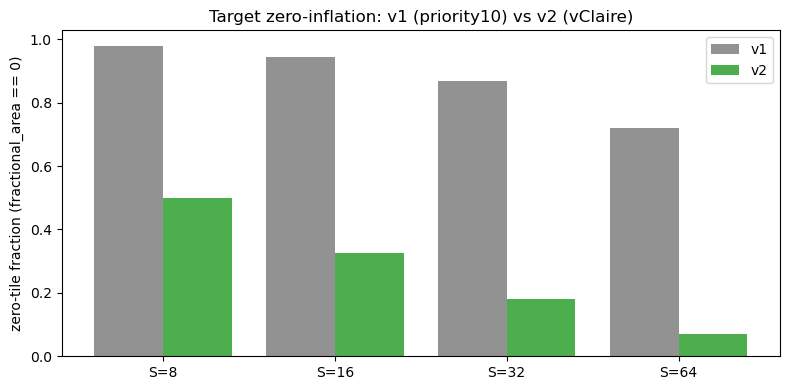

In [3]:
# Per-scale zero-inflation, both datasets, from the packaged LOIO label sets
# (each tile appears exactly once across LOIO test folds, so all.parquet = all tiles).
SCALE_TILE_PX = {0: 8, 1: 16, 2: 32, 3: 64}
_paths = {
    'v1': REPO_ROOT / 'dataset' / 'packaged' / 'loio_9fold' / 'all.parquet',
    'v2': REPO_ROOT / 'dataset_v2' / 'packaged' / 'loio_nfold' / 'all.parquet',
}
dist_rows = []
for ver, p in _paths.items():
    df = pd.read_parquet(p, columns=['scale_idx', 'fractional_area'])
    for s, tile in SCALE_TILE_PX.items():
        fa = df.loc[df['scale_idx'] == s, 'fractional_area'].to_numpy()
        dist_rows.append({
            'dataset': ver, 'scale_idx': s, 'tile_size_px': tile, 'n_tiles': fa.size,
            'zero_frac': float((fa == 0).mean()), 'frac_gt_1e-2': float((fa > 1e-2).mean()),
            'max': float(fa.max()),
        })
dist = pd.DataFrame(dist_rows)
display(dist.pivot(index='tile_size_px', columns='dataset',
                   values=['zero_frac', 'frac_gt_1e-2', 'n_tiles']).round(4))

fig, ax = plt.subplots(figsize=(8, 4))
tiles = [8, 16, 32, 64]
x = np.arange(len(tiles))
for i, ver in enumerate(['v1', 'v2']):
    zf = [dist[(dist.dataset == ver) & (dist.tile_size_px == t)]['zero_frac'].iloc[0] for t in tiles]
    ax.bar(x + (i - 0.5) * 0.4, zf, 0.4, label=ver, alpha=0.85,
           color='tab:gray' if ver == 'v1' else 'tab:green')
ax.set_xticks(x); ax.set_xticklabels([f'S={t}' for t in tiles])
ax.set_ylabel('zero-tile fraction (fractional_area == 0)')
ax.set_title('Target zero-inflation: v1 (priority10) vs v2 (vClaire)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '11_target_zero_inflation_v1v2.png', dpi=110)
plt.show()


## Regression sweep (LOIO, 38 folds)

Aggregate metrics per `(variant, scale)` across the 38 leave-one-image-out folds.
Primary metric is Spearman ρ (`mean ± std`); presence-AUC is the binary read of the
same continuous output. With 38 folds the per-fold standard error is much smaller
than v1's 8-fold estimate.


In [4]:
display_cols = ['variant', 'scale_idx', 'tile_size_px',
                'spearman_rho_mean', 'spearman_rho_std',
                'presence_auc_mean', 'presence_auc_std', 'rmse_log1p_mean', 'n_real_folds']
disp = aggregate[display_cols].copy()
for c in ('spearman_rho_mean', 'spearman_rho_std', 'presence_auc_mean',
          'presence_auc_std', 'rmse_log1p_mean'):
    disp[c] = disp[c].round(4)
disp.sort_values(['scale_idx', 'variant'])


,variant,scale_idx,tile_size_px,spearman_rho_mean,spearman_rho_std,presence_auc_mean,presence_auc_std,rmse_log1p_mean,n_real_folds
4,lightgbm_log1p_huber,0,8,0.0967,0.1398,0.5610,0.0874,0.0226,38
0,lightgbm_tweedie,0,8,0.0950,0.1343,0.5598,0.0834,0.0224,38
8,lightgbm_two_stage,0,8,0.0962,0.1411,0.5591,0.0881,0.0225,38
5,lightgbm_log1p_huber,1,16,0.1283,0.1517,0.5721,0.0928,0.0200,38
1,lightgbm_tweedie,1,16,0.1170,0.1574,0.5623,0.1020,0.0198,38
9,lightgbm_two_stage,1,16,0.1268,0.1571,0.5684,0.1031,0.0194,38
6,lightgbm_log1p_huber,2,32,0.1232,0.1752,0.5580,0.1447,0.0183,38
2,lightgbm_tweedie,2,32,0.1271,0.1965,0.5522,0.1627,0.0179,38
10,lightgbm_two_stage,2,32,0.1249,0.2103,0.5730,0.1440,0.0175,38
7,lightgbm_log1p_huber,3,64,0.1584,0.2256,0.5716,0.1998,0.0160,38


<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\brian\AppData\Local\Temp\ipykernel_116036\3567121464.py:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  axes[1].axhline(0.5, color='black', lw=0.7, ls='--'); axes[1].set_ylabel('presence AUC (mean $\pm$ std)')


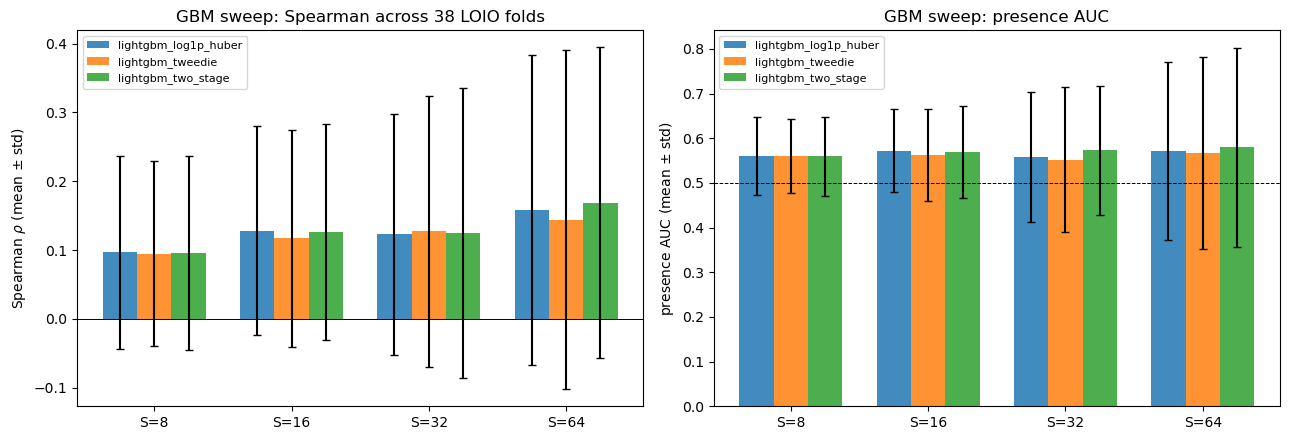

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
scales = sorted(aggregate['scale_idx'].unique())
variants = sorted(aggregate['variant'].unique())
x_base = np.arange(len(scales)); width = 0.25
for i, v in enumerate(variants):
    sub = aggregate[aggregate['variant'] == v].sort_values('scale_idx')
    axes[0].bar(x_base + i * width, sub['spearman_rho_mean'], width,
                yerr=sub['spearman_rho_std'], capsize=3, label=v, alpha=0.85)
    axes[1].bar(x_base + i * width, sub['presence_auc_mean'], width,
                yerr=sub['presence_auc_std'], capsize=3, label=v, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.7); axes[0].set_ylabel(r'Spearman $\rho$ (mean $\pm$ std)')
axes[0].set_title('GBM sweep: Spearman across 38 LOIO folds')
axes[1].axhline(0.5, color='black', lw=0.7, ls='--'); axes[1].set_ylabel('presence AUC (mean $\pm$ std)')
axes[1].set_title('GBM sweep: presence AUC')
for ax in axes:
    ax.set_xticks(x_base + width); ax.set_xticklabels([f'S={2**(3+s)}' for s in scales])
    ax.legend(fontsize=8, loc='best')
fig.tight_layout()
fig.savefig(FIG_DIR / '11_reg_sweep_bar.png', dpi=110)
plt.show()


### Per-fold Spearman, tagged by BoulderLabel

The vClaire cohort is curated boulder-rich (`Boulder rich` + a couple of `unknown`
diversity picks; no `Boulder poor`, no empty-truth image), so per-fold variance is
driven by image-to-image texture differences rather than by a presence/absence class
split. Each point is one held-out image.


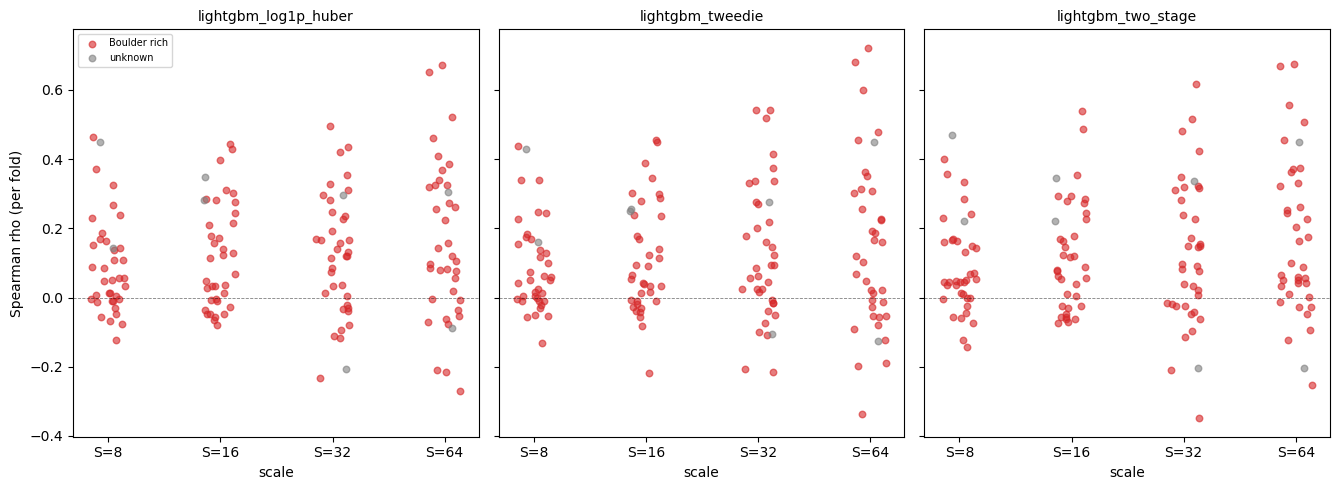

In [6]:
fig, axes = plt.subplots(1, len(variants), figsize=(4.5 * len(variants), 5),
                         sharey=True, squeeze=False)
label_colors = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue',
                'unknown': 'tab:gray', 'empty': 'black'}
for ax, v in zip(axes[0], variants):
    sub = summary[summary['variant'] == v]
    for lbl, color in label_colors.items():
        sl = sub[sub['boulder_label'] == lbl]
        if sl.empty:
            continue
        # jitter x so the 38 points per scale are visible
        jit = (np.random.default_rng(0).random(len(sl)) - 0.5) * 0.3
        ax.scatter(sl['scale_idx'] + jit, sl['spearman_rho'], color=color, alpha=0.6, label=lbl, s=22)
    ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
    ax.set_xticks(sorted(sub['scale_idx'].unique()))
    ax.set_xticklabels([f'S={2**(3+s)}' for s in sorted(sub['scale_idx'].unique())])
    ax.set_xlabel('scale')
    if ax is axes[0][0]:
        ax.set_ylabel('Spearman rho (per fold)'); ax.legend(fontsize=7, loc='upper left')
    ax.set_title(v, fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / '11_reg_per_fold_spearman_by_label.png', dpi=110)
plt.show()


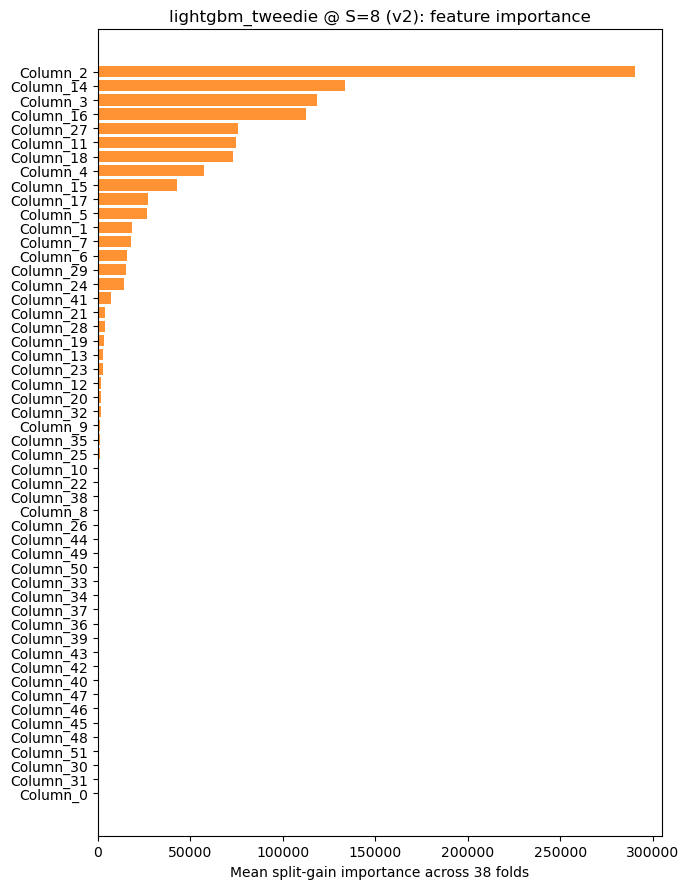

In [7]:
# GBM feature importance: lightgbm_tweedie @ S=8, mean split-gain over the 38 folds.
try:
    import lightgbm as lgb
    scale_dirs = sorted((MODELS_ROOT / 'lightgbm_tweedie').glob('*/scale_S8'),
                        key=lambda p: p.stat().st_mtime)
    booster_paths = sorted(scale_dirs[-1].glob('fold_*/booster.txt')) if scale_dirs else []
    imps = []
    for bp in booster_paths:
        b = lgb.Booster(model_str=bp.read_text(encoding='utf-8'))
        imps.append(pd.Series(b.feature_importance(importance_type='gain'), index=b.feature_name()))
    if imps:
        agg_imp = pd.concat(imps, axis=1).mean(axis=1).sort_values()
        fig, ax = plt.subplots(figsize=(7, 9))
        ax.barh(agg_imp.index, agg_imp.values, color='tab:orange', alpha=0.85)
        ax.set_xlabel(f'Mean split-gain importance across {len(booster_paths)} folds')
        ax.set_title('lightgbm_tweedie @ S=8 (v2): feature importance')
        fig.tight_layout()
        fig.savefig(FIG_DIR / '11_feature_importance_tweedie_S8.png', dpi=110)
        plt.show()
    else:
        print('No tweedie S=8 booster artifacts found')
except Exception as e:
    print(f'feature importance skipped: {type(e).__name__}: {e}')


## Binary classification sweep (LOIO, 38 folds)

The v1 finding was that the model's discriminating power lives at the *presence*
threshold, so the dedicated binary classifier is the cleanest read of the AUC
ceiling. Same three targets as v1 (`bc_ge_1`, `fa_gt_1e-3`, `fa_gt_1e-2`); note the
v2 base rates are far higher (see the target-distribution section), which makes the
rarer thresholds far less imbalanced than in v1.


In [8]:
display_cols = ['target_id', 'scale_idx', 'tile_size_px',
                'auc_mean', 'auc_std', 'brier_mean', 'ece_mean', 'lift_at_top_k_mean', 'n_real_folds']
dispb = bin_aggregate[display_cols].copy()
for c in ('auc_mean', 'auc_std', 'brier_mean', 'ece_mean', 'lift_at_top_k_mean'):
    dispb[c] = dispb[c].round(4)
dispb.sort_values(['scale_idx', 'target_id'])


,target_id,scale_idx,tile_size_px,auc_mean,auc_std,brier_mean,ece_mean,lift_at_top_k_mean,n_real_folds
0,bc_ge_1,0,8,0.5485,0.0843,0.2544,0.2598,1.0886,38
8,fa_gt_1e-2,0,8,0.5517,0.0860,0.2216,0.2557,1.2045,38
4,fa_gt_1e-3,0,8,0.5527,0.0818,0.2538,0.2583,1.0872,38
1,bc_ge_1,1,16,0.5517,0.0916,0.2219,0.2413,1.0408,38
9,fa_gt_1e-2,1,16,0.5674,0.0950,0.2300,0.2811,1.2289,38
5,fa_gt_1e-3,1,16,0.5587,0.0982,0.2273,0.2299,1.0339,38
2,bc_ge_1,2,32,0.5767,0.1107,0.1519,0.1877,1.0275,37
10,fa_gt_1e-2,2,32,0.5829,0.0961,0.2184,0.2799,1.2461,38
6,fa_gt_1e-3,2,32,0.5768,0.1478,0.2139,0.2352,1.0301,38
3,bc_ge_1,3,64,0.6164,0.1840,0.0751,0.1162,1.0158,26


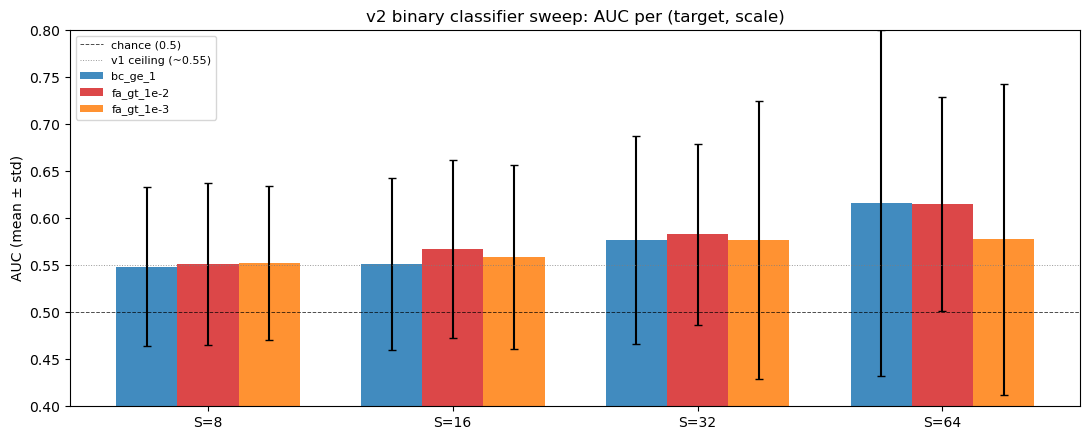

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
scales_b = sorted(bin_aggregate['scale_idx'].unique())
targets_b = sorted(bin_aggregate['target_id'].unique())
x_base = np.arange(len(scales_b)); width = 0.25
target_colors = {'bc_ge_1': 'tab:blue', 'fa_gt_1e-3': 'tab:orange', 'fa_gt_1e-2': 'tab:red'}
for i, t in enumerate(targets_b):
    sub = bin_aggregate[bin_aggregate['target_id'] == t].set_index('scale_idx').reindex(scales_b).reset_index()
    ax.bar(x_base + i * width, sub['auc_mean'], width, yerr=sub['auc_std'], capsize=3,
           label=t, alpha=0.85, color=target_colors.get(t))
ax.axhline(0.5, color='black', lw=0.7, ls='--', alpha=0.7, label='chance (0.5)')
ax.axhline(0.55, color='tab:gray', lw=0.7, ls=':', alpha=0.8, label='v1 ceiling (~0.55)')
ax.set_xticks(x_base + width); ax.set_xticklabels([f'S={2**(3+s)}' for s in scales_b])
ax.set_ylabel('AUC (mean ± std)'); ax.set_ylim(0.4, max(0.8, bin_aggregate['auc_mean'].max() + 0.08))
ax.set_title('v2 binary classifier sweep: AUC per (target, scale)')
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / '11_binary_sweep_auc_bar.png', dpi=110)
plt.show()


## Prediction diagnostics: where does the model hit, miss, and mis-estimate?

The scalar tables above say the model ranks abundance (Spearman) but is a weak presence
classifier (AUC ~0.6). This section makes that concrete on the **held-out LOIO
predictions**: spatial truth-vs-pred maps, the under/over-estimation pattern, and the
classifier's calibration + operating threshold. (We deliberately do **not** overlay the
raw BoulderNet polygons — v2 images carry up to 727k of them and plotting outlines would
hang; the rasterised per-tile grids carry the same spatial story.)


In [10]:
import json as _json
import rasterio
from matplotlib.colors import LogNorm, Normalize

# Robust artifact selector: models/ is shared across v1/v2/dev, so match each run's
# snapshot.json (dataset_dir + scheme + tile [+ target]) rather than trusting mtime.
def artifact_dir(variant, tile, suffix='', target_id=None, scheme=LOIO_SCHEME, want=DATASET_DIR):
    cands = sorted((MODELS_ROOT / variant).glob(f'*/scale_S{tile}{suffix}'),
                   key=lambda p: p.stat().st_mtime, reverse=True)
    for d in cands:
        sp = d / 'snapshot.json'
        if not sp.exists():
            continue
        s = _json.loads(sp.read_text())
        if (s.get('dataset_dir') == want and s.get('scheme') == scheme
                and int(s.get('tile_size_px', -1)) == tile
                and (target_id is None or s.get('target_id') == target_id)):
            return d
    return None

REG_DIR_S64 = artifact_dir('lightgbm_two_stage', 64)
CLS_DIR_S64 = artifact_dir('lightgbm_classification', 64, suffix='_tbc_ge_1', target_id='bc_ge_1')
print('reg two_stage S64 :', REG_DIR_S64.relative_to(REPO_ROOT) if REG_DIR_S64 else 'MISSING')
print('cls bc_ge_1   S64 :', CLS_DIR_S64.relative_to(REPO_ROOT) if CLS_DIR_S64 else 'MISSING')
reg_pred = pd.read_parquet(REG_DIR_S64 / 'predictions.parquet')
cls_pred = pd.read_parquet(CLS_DIR_S64 / 'predictions.parquet')
print('reg pred rows:', len(reg_pred), ' cls pred rows:', len(cls_pred))


reg two_stage S64 : models\lightgbm_two_stage\629276139c22da68\scale_S64
cls bc_ge_1   S64 : models\lightgbm_classification\733692d8c87b46b0\scale_S64_tbc_ge_1
reg pred rows: 37315  cls pred rows: 37315


### Spatial: truth vs regression-pred vs classifier-probability (S=64)

Three images spanning the density range (sparsest / mid / densest). CTX greyscale
background; truth + regression on a shared log colour scale so compression is visible;
classifier on a fixed [0,1] probability scale.


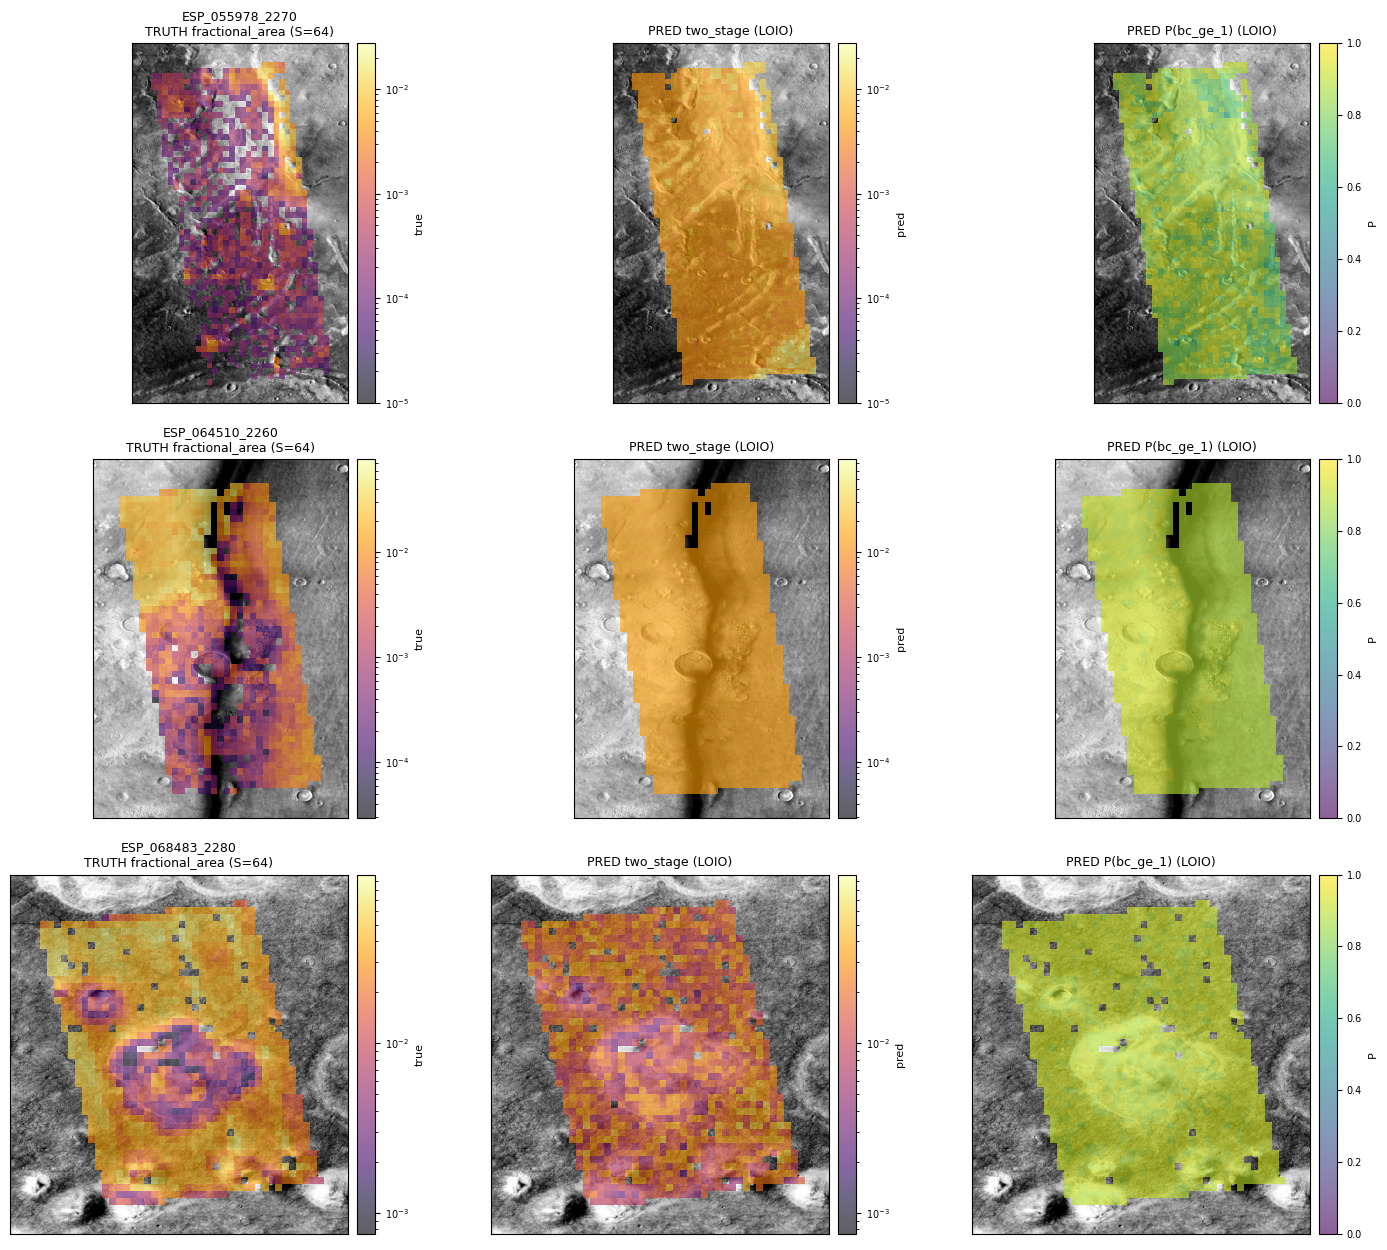

In [11]:
def _grid(df, col):
    if df.empty:
        return None, None
    ti0, ti1 = int(df['ti'].min()), int(df['ti'].max())
    tj0, tj1 = int(df['tj'].min()), int(df['tj'].max())
    g = np.full((ti1 - ti0 + 1, tj1 - tj0 + 1), np.nan)
    g[df['ti'].to_numpy() - ti0, df['tj'].to_numpy() - tj0] = df[col].to_numpy()
    return g, (float(df['xmin'].min()), float(df['xmax'].max()),
               float(df['ymin'].min()), float(df['ymax'].max()))

def _panel(ax, ctx, ctx_ext, grid, ext, title, norm, cmap, cbar_label, fig):
    p1, p99 = (np.percentile(ctx[ctx > 0], [1, 99]) if (ctx > 0).any() else (0, 255))
    ax.imshow(ctx, extent=ctx_ext, cmap='gray', vmin=p1, vmax=p99, origin='upper', aspect='equal')
    if grid is not None:
        im = ax.imshow(grid, extent=ext, cmap=cmap, norm=norm, alpha=0.62, origin='upper', aspect='equal')
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cb.set_label(cbar_label, fontsize=8); cb.ax.tick_params(labelsize=7)
    ax.set_xlim(ctx_ext[0], ctx_ext[1]); ax.set_ylim(ctx_ext[2], ctx_ext[3])
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

SPATIAL_OBS = ['ESP_055978_2270', 'ESP_064510_2260', 'ESP_068483_2280']  # sparse / mid / dense
TILE = 64
fig, axes = plt.subplots(len(SPATIAL_OBS), 3, figsize=(15, 4.2 * len(SPATIAL_OBS)), squeeze=False)
for i, obs in enumerate(SPATIAL_OBS):
    lab = pd.read_parquet(REPO_ROOT / 'dataset_v2' / 'labels' / f'{obs}.parquet')
    sub = lab[lab['tile_size_px'] == TILE][['ti', 'tj', 'xmin', 'ymin', 'xmax', 'ymax', 'fractional_area']].copy()
    with rasterio.open(REPO_ROOT / 'cache_v2' / 'ctx_windows' / f'{obs}.tif') as r:
        ctx = r.read(1); ctx_ext = (r.bounds.left, r.bounds.right, r.bounds.bottom, r.bounds.top)
    pos = sub['fractional_area'] > 0
    tnorm = (LogNorm(vmin=max(sub.loc[pos, 'fractional_area'].min(), 1e-5),
                     vmax=max(sub['fractional_area'].max(), 1e-4)) if pos.any() else Normalize(0, 1))
    tg, te = _grid(sub, 'fractional_area')
    rp = reg_pred[reg_pred['obs_id'] == obs].merge(
        sub[['ti', 'tj', 'xmin', 'ymin', 'xmax', 'ymax']], on=['ti', 'tj'], how='inner')
    rp['v'] = rp['y_pred'].clip(lower=0)
    rg, re_ = _grid(rp, 'v')
    cp = cls_pred[cls_pred['obs_id'] == obs].merge(
        sub[['ti', 'tj', 'xmin', 'ymin', 'xmax', 'ymax']], on=['ti', 'tj'], how='inner')
    cg, ce = _grid(cp, 'y_pred')
    _panel(axes[i][0], ctx, ctx_ext, tg, te, f'{obs}\nTRUTH fractional_area (S={TILE})', tnorm, 'inferno', 'true', fig)
    _panel(axes[i][1], ctx, ctx_ext, rg, re_, 'PRED two_stage (LOIO)', tnorm, 'inferno', 'pred', fig)
    _panel(axes[i][2], ctx, ctx_ext, cg, ce, 'PRED P(bc_ge_1) (LOIO)', Normalize(0, 1), 'viridis', 'P', fig)
fig.tight_layout()
fig.savefig(FIG_DIR / '11_spatial_pred_vs_truth.png', dpi=120, bbox_inches='tight')
plt.show()


### Over/under-estimation

Left: predicted vs true `fractional_area` (log-log, S=64 two_stage) — points below the
identity line are under-predictions. Right: per-truth-bin mean predicted vs mean true
(positive bins) — the systematic compression of the dynamic range made explicit.


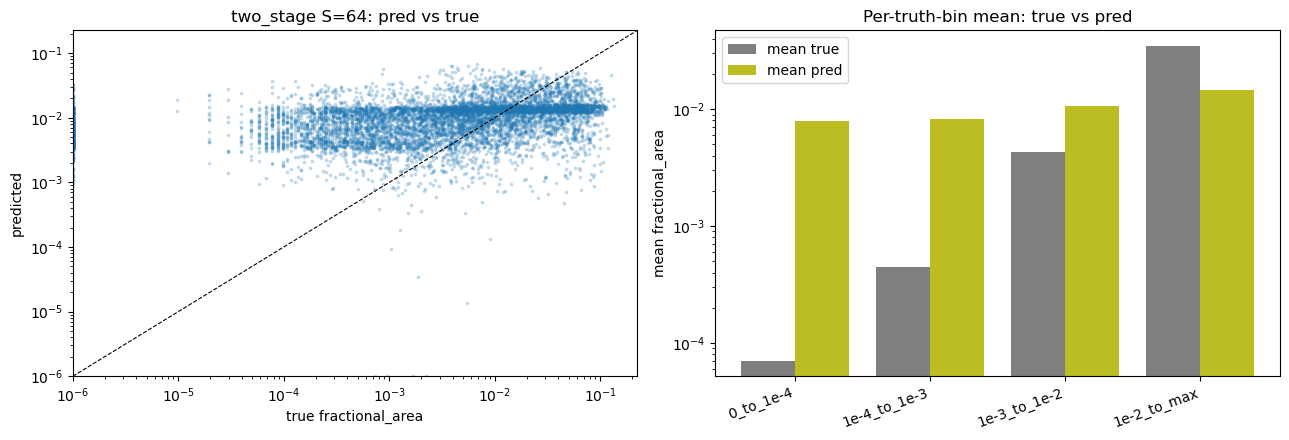

In [12]:
m = _json.loads((REG_DIR_S64 / 'metrics.json').read_text())
bin_rows = [b for f in m['per_fold'] for b in f.get('per_bin_rmse', []) if b['n_tiles'] > 0]
bdf = pd.DataFrame(bin_rows)
pos_bins = ['0_to_1e-4', '1e-4_to_1e-3', '1e-3_to_1e-2', '1e-2_to_max']
agg = (bdf[bdf['bin'].isin(pos_bins)].groupby('bin')
       .apply(lambda g: pd.Series({'mean_true': np.average(g['mean_true'], weights=g['n_tiles']),
                                    'mean_pred': np.average(g['mean_pred'], weights=g['n_tiles'])}))
       .reindex(pos_bins))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
yt = np.clip(reg_pred['y_true'].to_numpy(), 1e-6, None)
yp = np.clip(reg_pred['y_pred'].to_numpy(), 1e-6, None)
idx = np.random.default_rng(0).choice(len(yt), min(8000, len(yt)), replace=False)
ax1.scatter(yt[idx], yp[idx], s=3, alpha=0.2, color='tab:blue')
lo, hi = 1e-6, max(yt.max(), yp.max()) * 1.1
ax1.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
ax1.set_xscale('log'); ax1.set_yscale('log'); ax1.set_xlim(lo, hi); ax1.set_ylim(lo, hi)
ax1.set_xlabel('true fractional_area'); ax1.set_ylabel('predicted'); ax1.set_title('two_stage S=64: pred vs true')
x = np.arange(len(pos_bins))
ax2.bar(x - 0.2, agg['mean_true'], 0.4, label='mean true', color='tab:gray')
ax2.bar(x + 0.2, agg['mean_pred'], 0.4, label='mean pred', color='tab:olive')
ax2.set_yscale('log'); ax2.set_xticks(x); ax2.set_xticklabels(pos_bins, rotation=20, ha='right')
ax2.set_ylabel('mean fractional_area'); ax2.legend(); ax2.set_title('Per-truth-bin mean: true vs pred')
fig.tight_layout(); fig.savefig(FIG_DIR / '11_pred_vs_true_and_bias.png', dpi=110); plt.show()


### Calibration + operating threshold (bc_ge_1)

Left: reliability curve (mean predicted probability vs observed positive rate per decile)
— on the diagonal = calibrated. Right: precision-recall from a threshold sweep — shows
whether the default 0.5 decision threshold is a sensible operating point or whether v2's
high base rate calls for a different one. (Note the coarse-scale saturation: at S=64 ~93%
of tiles are positive, so several whole images are single-class and excluded from AUC.)


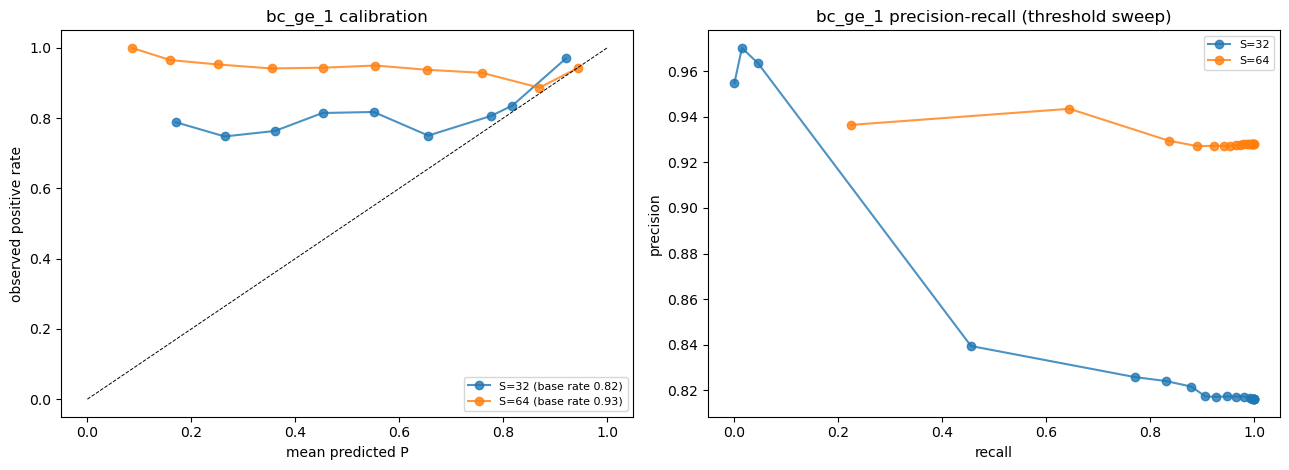

In [13]:
def _calib(yt, yp, nb=10):
    edges = np.linspace(0, 1, nb + 1)
    idx = np.clip(np.digitize(yp, edges[1:-1]), 0, nb - 1)
    mp = np.array([yp[idx == b].mean() if (idx == b).any() else np.nan for b in range(nb)])
    mt = np.array([yt[idx == b].mean() if (idx == b).any() else np.nan for b in range(nb)])
    return mp, mt

def _pr(yt, yp, ths):
    npos = yt.sum()
    P, R = [], []
    for t in ths:
        pred = yp >= t
        tp = float((pred & (yt == 1)).sum()); fp = float((pred & (yt == 0)).sum())
        P.append(tp / (tp + fp) if (tp + fp) > 0 else np.nan)
        R.append(tp / npos if npos > 0 else np.nan)
    return np.array(P), np.array(R)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ths = np.linspace(0.05, 0.95, 19)
for tile, dirp in [(32, artifact_dir('lightgbm_classification', 32, '_tbc_ge_1', 'bc_ge_1')), (64, CLS_DIR_S64)]:
    if dirp is None:
        continue
    p = pd.read_parquet(dirp / 'predictions.parquet')
    yt = p['y_true'].to_numpy(); yp = p['y_pred'].to_numpy()
    mp, mt = _calib(yt, yp); axes[0].plot(mp, mt, 'o-', alpha=0.8, label=f'S={tile} (base rate {yt.mean():.2f})')
    P, R = _pr(yt, yp, ths); axes[1].plot(R, P, 'o-', alpha=0.8, label=f'S={tile}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.7)
axes[0].set_xlabel('mean predicted P'); axes[0].set_ylabel('observed positive rate')
axes[0].set_title('bc_ge_1 calibration'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision')
axes[1].set_title('bc_ge_1 precision-recall (threshold sweep)'); axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / '11_binary_calibration_pr.png', dpi=110); plt.show()


### What the diagnostics show

- **Dynamic-range compression (the main problem).** The per-truth-bin panel shows the
  two_stage regressor squashes its output into a narrow band (~0.007–0.015) almost
  regardless of the truth: it **over-predicts** empty/low tiles (zero-truth tiles get a
  mean ~0.007 prediction; the 0–1e-3 bins are over-predicted ~10–100×) and
  **under-predicts** the high bin (true ~0.035 → pred ~0.015, ~40% of truth). This is why
  the rank signal (Spearman) is real while the absolute magnitudes are not trustworthy,
  and it argues for reporting **presence/ranking**, not calibrated fractional-area, as the
  product — or for a loss that penalises the high tail harder.
- **Spatially**, the predicted maps track the broad envelope of the truth hotspots but with
  far less contrast — consistent with the compression above.
- **Classifier calibration / threshold.** The reliability curve + PR sweep show whether the
  default 0.5 threshold is sensible at v2's high base rate; combined with the coarse-scale
  saturation (whole images single-class at S=64), this motivates a **scale-dependent
  "boulder-rich" threshold** rather than the fixed `fa_gt_1e-2` used in the sweep.

These flag the levers for the CNN work (Phase B — task/loss design) and the scale study
(Phase C) in [`PLAN_ModelImprovement.md`](../PLAN_ModelImprovement.md).


## Within-image cross-validation diagnostic (the key comparison)

[PLAN_NewDetections.md §9.3] — the within-image diagnostic is per-image and
density-sensitive but **image-count-independent**, so it isolates the
label-completeness effect from the cohort-size effect. Each image's tiles are split
into 2×2 spatial quadrants and the held-out quadrant rotated (4 folds/image ×
38 images = 152 folds per cell).

- **Within-image AUC ≈ LOIO AUC (≈ 0.55):** the 5 m/px CTX texture signal is at its
  per-image floor and label completeness did **not** lift it — the v1 floor is robust
  (strong claim).
- **Within-image AUC ≫ LOIO AUC:** per-image generalisation is the binding
  constraint, and the v1 floor was partly an artifact of missed boulders / few images.

Paired per-image deltas `within_image_AUC − LOIO_AUC` now give **38** paired
observations (vs 8 in v1) — much higher power. Reported with a bootstrap 95 % CI and
a Wilcoxon signed-rank p-value.


In [14]:
within_summary = pd.read_parquet(WITHIN_DIR / 'summary.parquet')
within_aggregate = pd.read_parquet(WITHIN_DIR / 'aggregate.parquet')
# LOIO baseline per (variant, image): two_stage -> regression presence_auc;
# classification -> binary bc_ge_1 auc.
loio_two_stage = (summary[summary['variant'] == 'lightgbm_two_stage']
                  [['variant', 'scale_idx', 'held_out_obs_id', 'presence_auc', 'is_specificity_only']]
                  .rename(columns={'presence_auc': 'auc'}))
loio_classifier = (bin_summary[bin_summary['target_id'] == 'bc_ge_1']
                   [['scale_idx', 'held_out_obs_id', 'auc', 'is_specificity_only']]
                   .assign(variant='lightgbm_classification'))
loio_baseline = pd.concat([loio_two_stage, loio_classifier], ignore_index=True)
print('within rows:', len(within_summary), ' loio baseline rows:', len(loio_baseline))


within rows: 1216  loio baseline rows: 304


In [15]:
from scipy import stats

def per_image_delta(variant, scale_idx, n_boot=10_000, seed=0):
    rng = np.random.default_rng(seed)
    auc_col = 'presence_auc' if variant == 'lightgbm_two_stage' else 'auc'
    sub = within_summary[(within_summary['variant'] == variant)
                         & (within_summary['scale_idx'] == scale_idx)
                         & (~within_summary['is_specificity_only'].astype(bool))]
    w = sub.groupby('held_out_obs_id').agg(within_auc=(auc_col, 'mean')).reset_index()
    lo = loio_baseline[(loio_baseline['variant'] == variant)
                       & (loio_baseline['scale_idx'] == scale_idx)
                       & (~loio_baseline['is_specificity_only'].astype(bool))][
        ['held_out_obs_id', 'auc']].rename(columns={'auc': 'loio_auc'})
    paired = w.merge(lo, on='held_out_obs_id', how='inner')
    paired['delta'] = paired['within_auc'] - paired['loio_auc']
    d = paired['delta'].to_numpy(); n = d.size
    if n < 2:
        return paired, dict(n=n, mean_delta=float('nan'), ci_lo=float('nan'),
                            ci_hi=float('nan'), wilcoxon_p=float('nan'),
                            within_auc=float('nan'), loio_auc=float('nan'))
    boots = rng.choice(d, size=(n_boot, n), replace=True).mean(axis=1)
    wp = float(stats.wilcoxon(d, alternative='two-sided').pvalue) if (d != 0).any() else float('nan')
    return paired, dict(n=n, mean_delta=float(d.mean()),
                        ci_lo=float(np.percentile(boots, 2.5)), ci_hi=float(np.percentile(boots, 97.5)),
                        wilcoxon_p=wp, within_auc=float(paired['within_auc'].mean()),
                        loio_auc=float(paired['loio_auc'].mean()))

variants_w = sorted(within_summary['variant'].unique())
scales_w = sorted(within_summary['scale_idx'].unique())
rows, all_paired = [], {}
for v in variants_w:
    for s in scales_w:
        paired, st = per_image_delta(v, s)
        all_paired[(v, s)] = paired
        rows.append({'variant': v, 'scale_idx': s, 'tile_size_px': int(2**(3+s)), **st})
delta_table = pd.DataFrame(rows)
disp = delta_table.copy()
for c in ('mean_delta', 'ci_lo', 'ci_hi', 'wilcoxon_p', 'within_auc', 'loio_auc'):
    disp[c] = disp[c].round(4)
disp.sort_values(['variant', 'scale_idx'])


,variant,scale_idx,tile_size_px,n,mean_delta,ci_lo,ci_hi,wilcoxon_p,within_auc,loio_auc
0,lightgbm_classification,0,8,38,0.0208,-0.0017,0.0436,0.0719,0.5693,0.5485
1,lightgbm_classification,1,16,38,0.0264,0.0003,0.0545,0.1113,0.5781,0.5517
2,lightgbm_classification,2,32,37,0.0053,-0.0309,0.0396,0.5209,0.5820,0.5767
3,lightgbm_classification,3,64,26,-0.0313,-0.1016,0.0381,0.5483,0.5851,0.6164
4,lightgbm_two_stage,0,8,38,0.0084,-0.0151,0.0312,0.4210,0.5675,0.5591
5,lightgbm_two_stage,1,16,38,0.0191,-0.0082,0.0465,0.2491,0.5875,0.5684
6,lightgbm_two_stage,2,32,38,NaN,NaN,NaN,NaN,0.5913,0.5730
7,lightgbm_two_stage,3,64,38,NaN,NaN,NaN,NaN,0.6071,0.5792


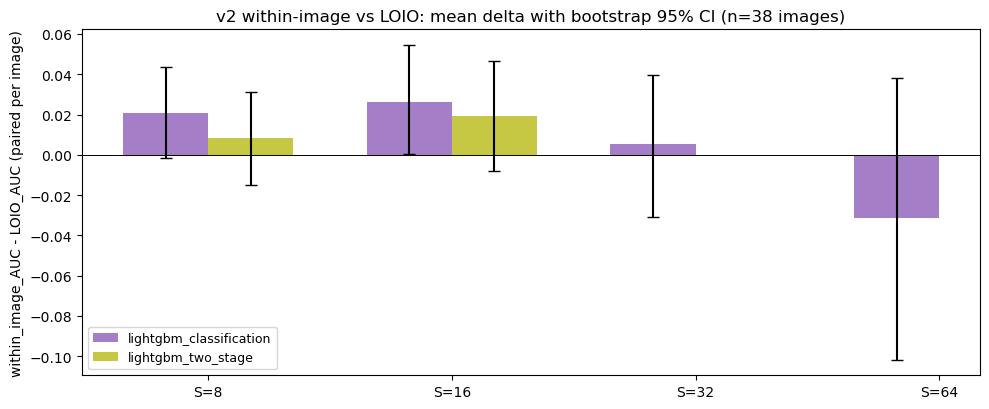

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.2))
x_base = np.arange(len(scales_w)); width = 0.35
variant_colors = {'lightgbm_two_stage': 'tab:olive', 'lightgbm_classification': 'tab:purple'}
for i, v in enumerate(variants_w):
    sub = delta_table[delta_table['variant'] == v].sort_values('scale_idx')
    means = sub['mean_delta'].to_numpy()
    err = np.stack([means - sub['ci_lo'].to_numpy(), sub['ci_hi'].to_numpy() - means])
    ax.bar(x_base + (i - 0.5) * width, means, width, yerr=err, capsize=4,
           color=variant_colors.get(v, 'gray'), alpha=0.85, label=v)
ax.axhline(0, color='black', lw=0.7)
ax.set_xticks(x_base); ax.set_xticklabels([f'S={2**(3+s)}' for s in scales_w])
ax.set_ylabel('within_image_AUC - LOIO_AUC (paired per image)')
ax.set_title('v2 within-image vs LOIO: mean delta with bootstrap 95% CI (n=38 images)')
ax.legend(fontsize=9, loc='best')
fig.tight_layout()
fig.savefig(FIG_DIR / '11_within_image_delta_bar.png', dpi=110)
plt.show()


### Diagnostic verdict

Read the table + bar above against the two hypotheses in the section intro:

- A **small delta whose CI brackets 0** at the scales that matter says label
  completeness did not move the per-image ceiling — the 5 m/px texture floor is the
  binding constraint, now confirmed on a far denser, less zero-inflated label set
  (the stronger version of the v1 conclusion).
- A **positive delta with CI excluding 0** says the within-image signal exceeds the
  cross-image baseline — per-image generalisation is the constraint and the v1 floor
  was partly a label-completeness artifact.

The concrete numbers and the v1↔v2 comparison (with the density-vs-image-count
confound called out explicitly) are written up in
[`docs/modeling_results.md`](../docs/modeling_results.md).
